In [1]:
import pandas as pd
import numpy as np
import joblib
from lime.lime_tabular import LimeTabularExplainer
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from alibi.explainers import AnchorTabular
from typing import Tuple, Any, List
import matplotlib.axes
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# I just dont want to see the warnings anymore lol
import warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

shap.initjs() # Enables us to generate SHAP plots

C:\Users\loren\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# We are calling our train_df as historical_df.
historical_df = pd.read_csv('../data/historical.csv')
misclassified_df = pd.read_csv('../data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("../data/model.joblib")

FileNotFoundError: [Errno 2] No such file or directory: '../data/corrected_false_negatives.csv'

In [ ]:
# Set up the features to be used
features = historical_df.columns[:-1]
X_hist = historical_df[features]

# Get the misclassified babies and their indices
X_hist['orig_index'] = X_hist.index

X_misclassified = X_hist.merge(
    misclassified_df,
    on=['baby_id', 'name', 'gender', 'date'],
    how='inner'
)

# Get the misclassified babies' indices and drop the index column
misclassified_indices = X_misclassified['orig_index'].tolist()
X_misclassified.drop(columns=['orig_index'], inplace=True)
X_hist.drop(columns=['orig_index'], inplace=True)

# Executive Summary of Local Explainable AI

The DataMonitors model for classifying babies as healthy or at risk is heavily driven by jaundice levels. SHAP analysis of false negatives shows that jaundice is the dominant feature pushing predictions toward healthy, even when babies are actually at risk. To understand why, we first show how the model prioritizes jaundice as its main basis for classification. Using Anchors, we illustrate why prioritizing jaundice initially makes sense because low jaundice alone is often enough for a confident prediction that a baby is healthy.

However, the model clearly overrelies on this variable. ICE plots reveal that as jaundice increases, the predicted risk probability approaches 100 percent, while other features like oxygen saturation and heart rate peak at roughly 80 percent and 50 percent, respectively. We reinforce this with LIME by comparing two similar babies, showing how differences in jaundice alone can sway the model’s prediction.

Overall, jaundice not only dominates decision-making but also drives false negatives while other features remain secondary in influence.

# Anchor

As shown in the table below, the Anchor identifies a simple and clear rule: if a baby’s jaundice level is $\leq$ 4.30 mg/dL, the model predicts the baby to be healthy (class 0). Whenever this rule applies, the model is always correct, which is why the precision is 1.0 and there are no misclassifications. The coverage of 0.75 means that this rule applies to about three-quarters of all babies, capturing the majority of cases. This shows that a single threshold explains much of the model’s behavior, since low jaundice alone is enough for a confident healthy prediction. It also explains why the model relies so heavily on jaundice—it is a strong and robust feature. However, this reliance becomes problematic when the model begins to overdepend on jaundice, as we will see with LIME and ICE.

In [ ]:
# Drop unused columns
dropped_columns = ['baby_id', 'name', 'date', 'apgar_score']
X_encoded = X_hist.copy()
X_encoded = X_encoded.drop(columns=dropped_columns)

# Identify categorical features
preprocessor = old_model['preprocess']
categorical_features = preprocessor.transformers_[1][2]  
categorical_indices = [X_encoded.columns.get_loc(col) for col in categorical_features]

# Encode categorical columns as integers
categorical_names = {}
for idx, feature in zip(categorical_indices, categorical_features):
    X_encoded[feature] = X_encoded[feature].astype("category").cat.codes
    categorical_names[idx] = list(X_encoded[feature].astype("category").cat.categories)

# Ensure numeric columns are float
numeric_features = [col for col in X_encoded.columns if col not in categorical_features]
X_encoded[numeric_features] = X_encoded[numeric_features].astype(float)

# ColumnTransformer
recreated_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), preprocessor.transformers_[0][2]),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), preprocessor.transformers_[1][2])
    ],
    remainder='drop'   # drops baby_id, name, date (in case it hasn't been dropped beforehand)
)

recreated_preprocessor.fit(X_encoded)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [3]:
# Wrap model prediction for Anchor
def predictor(X):
    baby_df = pd.DataFrame(X, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict(baby_transformed)

explainer = AnchorTabular(
    predictor=predictor,
    feature_names=X_encoded.columns.tolist(),
    categorical_names=categorical_names
)

# Fit on training data
explainer.fit(
    X_encoded.values.astype(np.float64),
    disc_perc=[25, 50, 75]
)

# create a dict
anchors = {}
# Pick an instance to explain
for idx in misclassified_indices:
    anchors[idx] = {}
    instance = X_encoded.iloc[idx].values.reshape(1, -1).astype(np.float64)

    # Generate explanation
    explanation = explainer.explain(instance)

    anchors[idx]['Anchor rule'] = explanation.anchor
    anchors[idx]['Precision'] = explanation.precision
    anchors[idx]['Coverage'] = explanation.coverage

# Convert to DataFrame, making anchors tuples or strings
df_anchors = pd.DataFrame.from_dict(anchors, orient='index')
# convert list to string
df_anchors['Anchor rule'] = df_anchors['Anchor rule'].apply(lambda x: ' & '.join(x))  

# Group by anchor rule and compute median + count
summary = df_anchors.groupby('Anchor rule').agg(
    Precision=('Precision', 'median'),
    Coverage=('Coverage', 'median'),
    Count=('Anchor rule', 'count')  # how often each anchor appears
).sort_values(['Count', 'Precision'], ascending=[False, False])

summary


NameError: name 'X_encoded' is not defined

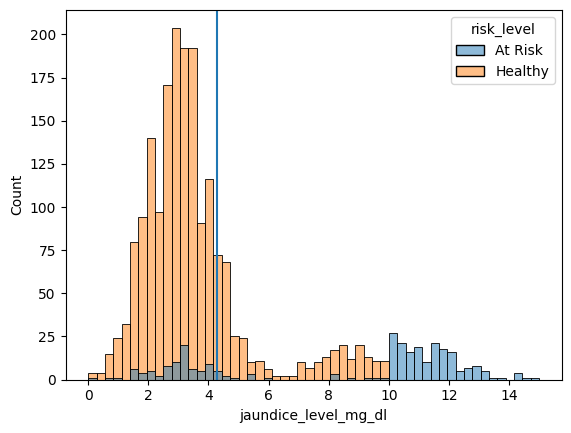

In [4]:
import seaborn as sns
sns.histplot(data=historical_df,
             x='jaundice_level_mg_dl',
             hue='risk_level',
)

plt.axvline(x=4.30);

# LIME

To show a concrete example of how the model overrelied on jaundice, we used LIME to compare two similar babies (except for the jaundice level). We manually reviewed the misclassified cases and identified the most similar babies, Nicole and Tara. Both had comparable heart rates, oxygen saturation levels, and weight. The primary difference between them was their jaundice level, with Nicole exhibiting a low jaundice level and Tara a high one. The model assigned a higher probability of being at risk to Tara (29%) and a lower probability to Nicole (9%), indicating that jaundice was the main factor influencing the model’s confidence in these predictions.

In [5]:
# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_encoded.values,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Healthy', 'At Risk'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    kernel_width=3
)

# Create an anonymous function where given a sample, it predicts using the rf model
def predict_fn(baby):
    baby_df = pd.DataFrame(baby, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict_proba(baby_transformed)

for i in [57, 1341]:
    misclassified_baby = historical_df.loc[i]
    print(f"{misclassified_baby['name']} of index {i} "
          f"was misclassified as healthy on {misclassified_baby['date']}")

    exp = explainer.explain_instance(
        X_encoded.iloc[i].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    exp.show_in_notebook(show_all=True)

NameError: name 'X_encoded' is not defined

# Individual Conditional Expectation (ICE)

The ICE plots in Figure 7 show individual predicted risks for babies across different feature values. Unlike PDPs, which show average effects, ICE plots let us focus on individual babies, especially the misclassified ones. The red dots mark each baby’s actual feature values, anchoring predictions to real observations. Misclassified babies tend to have feature values in ranges where the model is less confident. Interactions with other features create variability, so even the same value of jaundice, heart rate, or oxygen saturation can lead to different predicted risks.

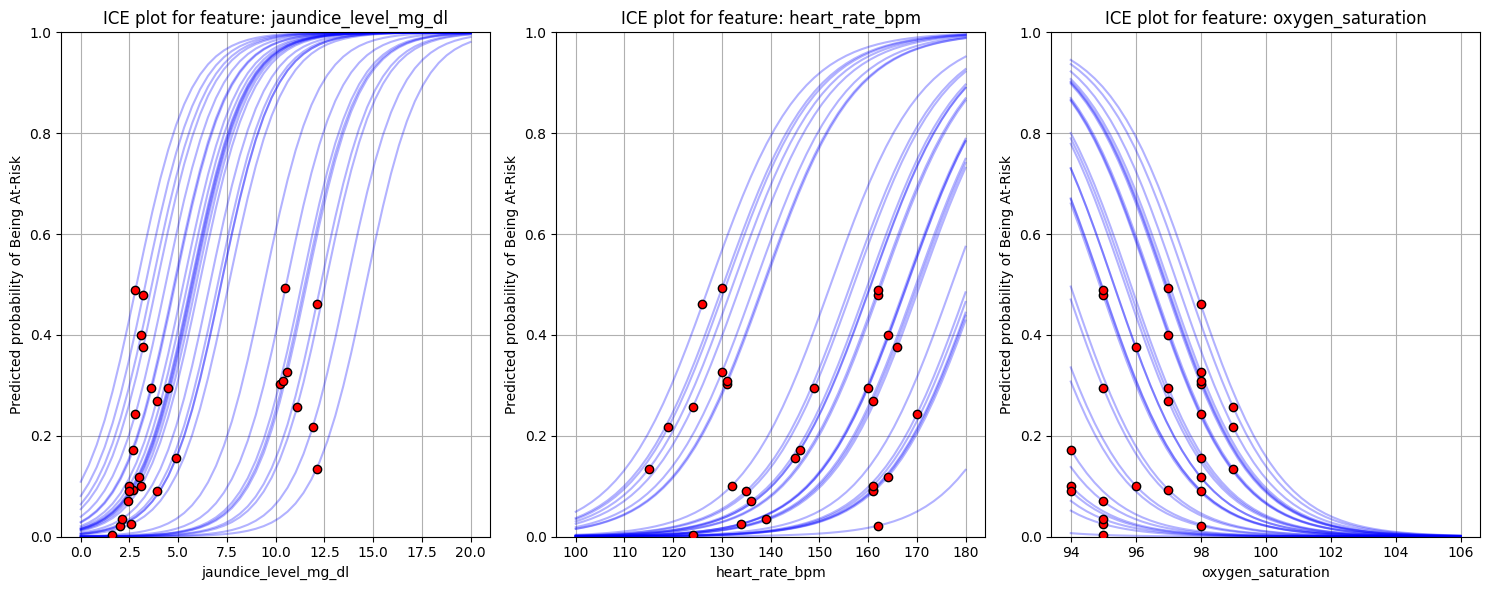

In [ ]:
def plot_ice_multiple_with_dots(
    instances: pd.DataFrame,
    feature: str,
    value_range: np.ndarray | List[float] | List[int],
    ax: matplotlib.axes.Axes,
    preprocessor: BaseEstimator | TransformerMixin,  
    model: BaseEstimator, 
    ylim: Tuple[float, float] = (0, 1),
    alpha: float = 0.3,
    line_color: str = "blue",
    dot_color: str = "red"
) -> None:
    """
    Plot ICE curves for a feature across multiple instances with a dot at each instance's original value.
    """
    for i in range(len(instances)):
        instance = instances.iloc[[i]]
        preds: List[float] = []
        for val in value_range:
            temp: pd.DataFrame = instance.copy()
            temp[feature] = val
            temp_transformed: np.ndarray = preprocessor.transform(temp)
            pred: float = model.predict_proba(temp_transformed)[0, 1]
            preds.append(pred)
        
        # Plot the ICE curve
        ax.plot(value_range, preds, marker=None, alpha=alpha, color=line_color)
        
        # Plot a dot at the original feature value
        orig_value = instance[feature].values[0]
        orig_pred = model.predict_proba(preprocessor.transform(instance))[0, 1]
        ax.scatter(orig_value, orig_pred, color=dot_color, edgecolor="black", zorder=5)
    
    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted probability of Being At-Risk")
    ax.set_title(f"ICE plot for feature: {feature}")
    ax.set_ylim(*ylim)
    ax.grid(True)

# Example usage for misclassified babies
misclassified_babies = X_encoded.iloc[misclassified_indices]  # replace misclassified_mask with your boolean mask
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# The actual min and max
# features_info = [
#     ("jaundice_level_mg_dl", np.linspace(0, 15, 50)),
#     ("heart_rate_bpm", np.linspace(100, 173, 50)),
#     ("oxygen_saturation", np.linspace(94, 101, 50))
# ]

# What if scenario
features_info = [
    ("jaundice_level_mg_dl", np.linspace(0, 20, 50)),
    ("heart_rate_bpm", np.linspace(100, 180, 50)),
    ("oxygen_saturation", np.linspace(94, 106, 50))
]

for ax, (feature, value_range) in zip(axs, features_info):
    plot_ice_multiple_with_dots(
        misclassified_babies, feature, value_range, ax,
        recreated_preprocessor, old_model['clf']
    )

plt.tight_layout()
plt.show()


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import partial_dependence
import numpy as np

def h_statistic(model, X, feat1, feat2, grid_resolution=20):
    """
    Compute Friedman’s H-statistic between two features (feat1, feat2).
    
    Parameters:
    -----------
    model : trained sklearn model or pipeline with predict_proba
    X : pandas DataFrame
        Input features (not yet transformed by preprocessors)
    feat1, feat2 : str
        Names of the two features to compute interaction for
    grid_resolution : int
        How many grid points for PDPs (higher = more accurate, slower)
        
    Returns:
    --------
    float : H-statistic value (0 = no interaction, 1 = pure interaction)
    """
    
    features = [feat1, feat2]
    
    # Joint 2D PDP
    pd_joint = partial_dependence(model, X, features=features,
                                  grid_resolution=grid_resolution,
                                  kind="average")
    pd_joint_values = pd_joint["average"][0]
    
    # Individual PDPs
    pd_feat1 = partial_dependence(model, X, features=[feat1],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    pd_feat2 = partial_dependence(model, X, features=[feat2],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    
    # Reshape for broadcasting
    pd_feat1 = pd_feat1.reshape(-1, 1)
    pd_feat2 = pd_feat2.reshape(1, -1)
    
    # Numerator: variance of interaction effect
    interaction_effect = pd_joint_values - pd_feat1 - pd_feat2
    numerator = np.var(interaction_effect)
    
    # Denominator: variance of joint PDP
    denominator = np.var(pd_joint_values)
    
    h_val = np.sqrt(numerator / denominator) if denominator > 0 else 0.0
    return h_val

# Have a pipeline for the h_statistic
model_pipeline = Pipeline(steps=[
    ('preprocess', recreated_preprocessor),
    ('clf', old_model['clf'])
])

def bootstrap_h(model, X, feat1, feat2, n_boot=50):
    """Do this many times"""
    vals = []
    n = len(X)
    for _ in range(n_boot):
        sample_idx = np.random.choice(n, n, replace=True)
        Xs = X.iloc[sample_idx]
        vals.append(h_statistic(model, Xs, feat1, feat2))
    vals = np.array(vals)
    return vals.mean(), np.percentile(vals, [2.5,97.5])

mean_h_jaundice_oxygen, ci_jaundice_oxygen = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'oxygen_saturation', n_boot=50)
print("H mean between jaundice and oxygen_saturation:", mean_h_jaundice_oxygen, "95% CI:", ci_jaundice_oxygen)

mean_h_jaundice_heart, ci_jaundice_heart = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'heart_rate_bpm', n_boot=50)
print("H mean between jaundice and heart_rate_bpm:", mean_h_jaundice_heart, "95% CI:", ci_jaundice_heart)

mean_h_oxygen_heart, ci_oxygen_heart = bootstrap_h(model_pipeline, X_encoded, 'oxygen_saturation', 'heart_rate_bpm', n_boot=50)
print("H mean between oxygen saturation and heart_rate_bpm:", mean_h_oxygen_heart, "95% CI:", ci_oxygen_heart)

NameError: name 'recreated_preprocessor' is not defined

In [7]:
#ShapTreeExplainer
#CounterFactuals